📅 День 8 — Практика по torchvision.transforms

Работай с любыми картинками (кошки/собаки, свои фото, датасеты).
База (документация, к которой обращаться):
👉 https://pytorch.org/vision/stable/transforms.html


✅ Задание 1 — Resize (изменение размера)
🎯 Цель

Понять, зачем все изображения приводят к одному размеру.

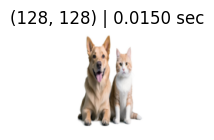

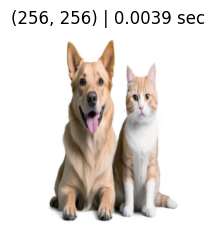

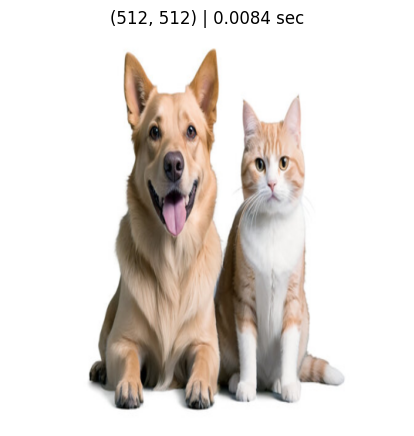

In [1]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import time

img = Image.open("data/dog-cat.jpg")

sizes = [(128,128), (256,256), (512,512)]

for size in sizes:
    
    start_time = time.time()
    
    transform = transforms.Resize(size)
    img_resized = transform(img)
    
    elapsed = time.time() - start_time
    
    # Получаем реальные размеры изображения
    w, h = img_resized.size
    
    dpi = 100
    plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi)
    
    plt.imshow(img_resized)
    plt.title(f"{size} | {elapsed:.4f} sec")
    plt.axis("off")
    
    plt.show()

✅ Задание 2 — Normalize (нормализация)
🎯 Цель

Понять, как нейросети “видят” изображения.

🧠 Зачем нужна нормализация изображений?

Коротко:
👉 чтобы нейросеть училась быстрее, стабильнее и точнее.

Теперь по-человечески 👇

🎯 1) Нейросети плохо работают с “большими числами”

Пиксели изображения без нормализации:

0 … 255


Для сети это большие значения.
А градиентный спуск любит данные около нуля.

После нормализации:

примерно -1 … 1


👉 оптимизация становится стабильнее.

⚡ 2) Быстрее обучение

Если данные не нормализованы:

градиенты скачут

лосс колеблется

обучение медленное

Если нормализованы:

✅ smoother gradients
✅ быстрее сходится
✅ меньше проблем с learning rate

📏 3) Все признаки в одном масштабе

Представь:

один канал 0–255

другой 0–1

Сеть начнет “любить” один больше другого.

Нормализация делает вклад каналов равным.

In [1]:
import torch
import torchvision
import numpy as np

print(torch.__version__)
print(torchvision.__version__)
print(np.__version__)

2.0.1+cu118
0.15.2+cu118
1.26.4


In [9]:
!pip install numpy==1.26.4

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img_tensor = transform(img)

print(img_tensor.shape)
print(img_tensor.min(), img_tensor.max())

torch.Size([3, 224, 224])
tensor(-2.1008) tensor(2.6400)



Augmentations 
=========

✅ Задание 3 — Augmentations (самое интересное)
🎯 Цель

Научиться искусственно увеличивать датасет.

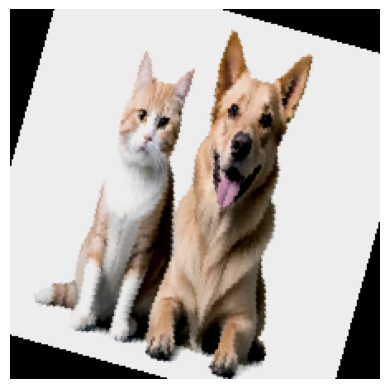

In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=1),
    transforms.RandomRotation(30),
    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.5
    )
])

aug_img = transform(img)

plt.imshow(aug_img)
plt.axis("off")
plt.show()


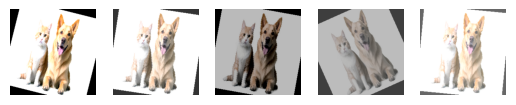

In [3]:
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(transform(img))
    plt.axis("off")
plt.show()

✅ Задание 4 — Compose pipeline
🎯 Цель

Собрать реальный pipeline как в боевых задачах.

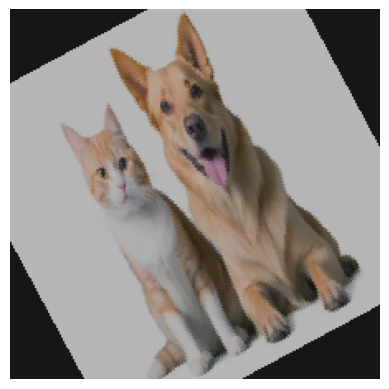

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

aug_img = transform(img)

plt.imshow(aug_img)
plt.axis("off")
plt.show()